#**PERSONAL PI**

##**INITIAL DATA INSPECTION**

In [18]:
import pandas as pd

df_pi = pd.read_excel("uc3m-personal-pi-2023-anonimizado.xlsx")

print("Dataset shape:", df_pi.shape)
print("\nColumns:")
print(df_pi.columns)

print("\nData types:")
print(df_pi.dtypes)

print("\nMissing values:")
print(df_pi.isnull().sum().sort_values(ascending=False).head(15))

df_pi.head()

Dataset shape: (809, 45)

Columns:
Index(['IMPORTANTE', 'cod_universidad', 'des_universidad', 'anio',
       'cod_pais_nacionalidad', 'des_pais_nacionalidad',
       'cod_continente_nacionalidad', 'des_continente_nacionalidad',
       'lat_pais_nacionalidad', 'lon_pais_nacionalidad',
       'cod_agregacion_paises_nacionalidad',
       'des_agregacion_paises_nacionalidad', 'cod_genero', 'des_genero',
       'anio_nacimiento', 'cod_tipo_personal_investigacion',
       'des_tipo_personal_investigacion',
       'cod_modalidad_personal_investigacion',
       'des_modalidad_personal_investigacion', 'cod_tipo_organismo',
       'des_tipo_organismo', 'cod_dedicacion', 'des_dedicacion',
       'duracion_meses', 'cod_titulo_doctorado', 'des_titulo_doctorado',
       'cod_pais_doctorado', 'des_pais_doctorado', 'lat_pais_doctorado',
       'lon_pais_doctorado', 'cod_continente_doctorado',
       'des_continente_doctorado', 'cod_agregacion_paises_doctorado',
       'des_agregacion_paises_doctorado'

,IMPORTANTE,cod_universidad,des_universidad,anio,cod_pais_nacionalidad,des_pais_nacionalidad,cod_continente_nacionalidad,des_continente_nacionalidad,lat_pais_nacionalidad,lon_pais_nacionalidad,...,des_universidad_doctorado,anio_lectura_tesis,anio_resolucion_convocatoria,anio_incorporacion,cod_tipo_unidad_responsable,des_tipo_unidad_responsable,cod_unidad_responsable,des_unidad_responsable,cod_area,des_area
0,LOS DATOS DE ESTA FILA NO CORRESPONDEN A UN SÓ...,36,Universidad Carlos III de Madrid,2023,724,España,150,Europa,40.463667,-3.74922,...,NaN,NaN,2020,2020,2.0,Departamento,55001933.0,Departamento de Ingeniería de Sistemas y Autom...,NaN,NaN
1,LOS DATOS DE ESTA FILA NO CORRESPONDEN A UN SÓ...,36,Universidad Carlos III de Madrid,2023,724,España,150,Europa,40.463667,-3.74922,...,NaN,NaN,2020,2019,2.0,Departamento,55001929.0,Departamento de Ingeniería Telemática,NaN,NaN
2,LOS DATOS DE ESTA FILA NO CORRESPONDEN A UN SÓ...,36,Universidad Carlos III de Madrid,2023,724,España,150,Europa,40.463667,-3.74922,...,NaN,NaN,2020,2018,2.0,Departamento,55001936.0,Departamento de Mecánica de Medios Continuos y...,NaN,NaN
3,LOS DATOS DE ESTA FILA NO CORRESPONDEN A UN SÓ...,36,Universidad Carlos III de Madrid,2023,724,España,150,Europa,40.463667,-3.74922,...,NaN,NaN,2020,2020,2.0,Departamento,55001939.0,Departamento de Ciencia e Ingeniería de Materi...,NaN,NaN
4,LOS DATOS DE ESTA FILA NO CORRESPONDEN A UN SÓ...,36,Universidad Carlos III de Madrid,2023,724,España,150,Europa,40.463667,-3.74922,...,NaN,NaN,2020,2020,2.0,Departamento,55001916.0,Departamento de Economía,NaN,NaN


##**DATA PREPROCESSING**

In [19]:
import pandas as pd

# -----------------------------
# Drop irrelevant columns
# -----------------------------
cols_to_drop = [
    "IMPORTANTE",
    "cod_universidad",
    "des_universidad",
    "cod_pais_nacionalidad",
    "cod_continente_nacionalidad",
    "des_continente_nacionalidad",
    "cod_agregacion_paises_nacionalidad",
    "des_agregacion_paises_nacionalidad",
    "cod_genero",
    "cod_tipo_personal_investigacion",
    "cod_modalidad_personal_investigacion",
    "cod_dedicacion",
    "des_titulo_doctorado",
    "cod_pais_doctorado",
    "anio_lectura_tesis",
    "anio_resolucion_convocatoria",
    "cod_tipo_organismo",
    "des_tipo_organismo",
    "cod_area",
    "des_area",
    "cod_continente_doctorado",
    "des_continente_doctorado",
    "cod_agregacion_paises_doctorado",
    "des_agregacion_paises_doctorado",
    "cod_pais_doctorado",
    "des_pais_doctorado",
    "cod_tipo_unidad_responsable",
    "des_tipo_unidad_responsable",
    "des_unidad_responsable",
    "cod_universidad_doctorado",
    "lat_pais_nacionalidad",
    "lon_pais_nacionalidad",
    "lat_pais_doctorado",
    "lon_pais_doctorado"
]

df_pi = df_pi.drop(columns=cols_to_drop)

# -----------------------------
# Standardize text columns
# -----------------------------
text_cols = df_pi.select_dtypes(include="object").columns

for col in text_cols:
    df_pi[col] = df_pi[col].astype(str).str.strip()

# -----------------------------
# Convert numeric columns
# -----------------------------
numeric_cols = [
    "anio_nacimiento",
    "duracion_meses",
    "anio_incorporacion"
]

df_pi[numeric_cols] = df_pi[numeric_cols].apply(pd.to_numeric, errors="coerce")
df_pi["cod_unidad_responsable"] = df_pi["cod_unidad_responsable"].astype("Int64")

# -----------------------------
# Check result
# -----------------------------
print("Clean dataset shape:", df_pi.shape)

print("\nMissing values:")
print(df_pi.isnull().sum().sort_values(ascending=False).head(15))

df_pi.head()

# -----------------------------
# Export cleaned dataset
# -----------------------------
df_pi.to_csv("uc3m_pi_clean.csv", index=False)

Clean dataset shape: (809, 12)

Missing values:
cod_unidad_responsable                  384
anio                                      0
des_genero                                0
des_pais_nacionalidad                     0
anio_nacimiento                           0
des_tipo_personal_investigacion           0
des_dedicacion                            0
des_modalidad_personal_investigacion      0
duracion_meses                            0
cod_titulo_doctorado                      0
des_universidad_doctorado                 0
anio_incorporacion                        0
dtype: int64


##**SHORT EDA**

In [20]:
# Basic information about the dataset
df_pi.info()

# Descriptive statistics for numeric variables
df_pi.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 809 entries, 0 to 808
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   anio                                  809 non-null    int64 
 1   des_pais_nacionalidad                 809 non-null    object
 2   des_genero                            809 non-null    object
 3   anio_nacimiento                       809 non-null    int64 
 4   des_tipo_personal_investigacion       809 non-null    object
 5   des_modalidad_personal_investigacion  809 non-null    object
 6   des_dedicacion                        809 non-null    object
 7   duracion_meses                        809 non-null    int64 
 8   cod_titulo_doctorado                  809 non-null    int64 
 9   des_universidad_doctorado             809 non-null    object
 10  anio_incorporacion                    809 non-null    int64 
 11  cod_unidad_responsable          

,anio,anio_nacimiento,duracion_meses,cod_titulo_doctorado,anio_incorporacion,cod_unidad_responsable
count,809.0,809.000000,809.000000,809.000000,809.000000,425.0
mean,2023.0,1991.993820,23.907293,0.237330,2020.864030,55002413.284706
std,0.0,8.281777,18.605867,0.425709,2.799629,909.651927
min,2023.0,1957.000000,0.000000,0.000000,2006.000000,55001916.0
25%,2023.0,1989.000000,9.000000,0.000000,2020.000000,55001920.0
50%,2023.0,1994.000000,23.000000,0.000000,2022.000000,55001934.0
75%,2023.0,1998.000000,36.000000,0.000000,2023.000000,55001940.0
max,2023.0,2004.000000,156.000000,1.000000,2023.000000,55004355.0


In [21]:
# Gender distribution
df_pi["des_genero"].value_counts()

,count
des_genero,
Hombre,544
Mujer,265


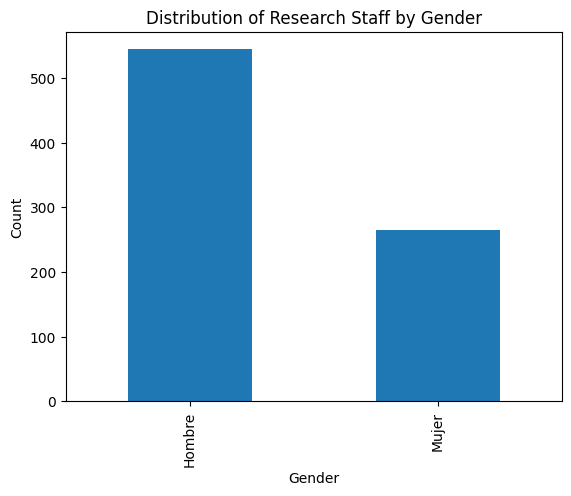

In [22]:
import matplotlib.pyplot as plt

df_pi["des_genero"].value_counts().plot(kind="bar")
plt.title("Distribution of Research Staff by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

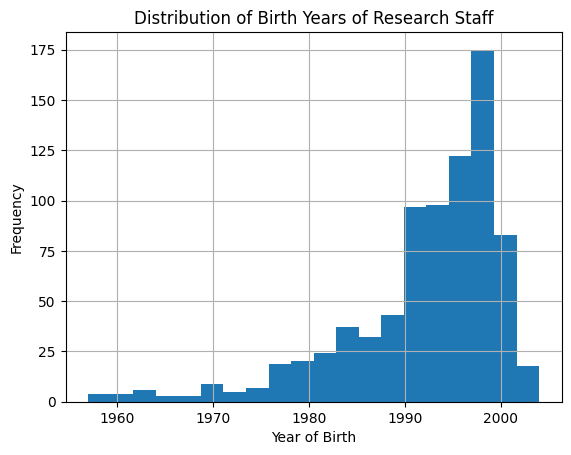

In [23]:
# Age distribution

df_pi["anio_nacimiento"].hist(bins=20)

plt.title("Distribution of Birth Years of Research Staff")
plt.xlabel("Year of Birth")
plt.ylabel("Frequency")
plt.show()

In [24]:
# Nationality distribution

df_pi["des_pais_nacionalidad"].value_counts().head(10)

,count
des_pais_nacionalidad,
España,570
Italia,47
Cuba,16
Irán (República Islámica del),14
México,13
China,13
Colombia,13
Francia,9
Alemania,8


In [25]:
# Doctoral qualification

df_pi["cod_titulo_doctorado"].value_counts()

,count
cod_titulo_doctorado,
0,617
1,192


In [26]:
# Type of research staff

df_pi["des_tipo_personal_investigacion"].value_counts()

,count
des_tipo_personal_investigacion,
"Investigador de convocatorias públicas competitivas de ámbito universitario, local, autonómico, estatal o internacional",441
Personal técnico de apoyo a la investigación,360
"Investigador con cargo a proyectos de investigación, Art. 60 LOSU y a grupos de investigación",8
